In [ ]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 24.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

### Novo

In [ ]:
# @title Visualização dos dados
import pandas as pd

data_path = "/content/drive/MyDrive/gaitanalisys/data.csv"
df_data = pd.read_csv(data_path)

# print first 10 and last 10 rows concatenated
df_data_concat = pd.concat([df_data.head(10), df_data.tail(10)])
df_data_concat

,time,ax,ay,az,gx,gy,gz
0,1.746730e+09,-0.85,-9.26,-7.88,0.01,0.00,-0.03
1,1.746730e+09,-0.84,-9.33,-7.77,0.05,-0.01,-0.03
2,1.746730e+09,-0.78,-9.41,-7.51,0.06,0.00,-0.03
3,1.746730e+09,-0.87,-9.40,-7.50,0.04,0.02,-0.02
4,1.746730e+09,-0.86,-9.36,-7.60,0.01,0.02,-0.02
5,1.746730e+09,-0.80,-9.30,-7.65,0.02,0.03,-0.02
6,1.746730e+09,-0.85,-9.34,-7.72,0.06,0.02,-0.03
7,1.746730e+09,-0.81,-9.40,-7.64,0.09,0.01,-0.03
8,1.746730e+09,-0.77,-9.39,-7.57,0.08,0.02,-0.03
9,1.746730e+09,-0.79,-9.41,-7.47,0.04,0.02,-0.02


In [ ]:
# 1) Instalação (descomente se necessário)
#!pip install visualkeras

# @title 2) Imports gerais
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import visualkeras

import joblib

# ---------------------------------------------------
# 3) Monte o Drive
drive.mount('/content/drive')

# 4) Dicionário de tamanhos de fonte
fonts = {
    'axis'  : 18,
    'title' : 20,
    'notes' : 12,
    'legend': 14
}
# ---------------------------------------------------

# 5) Funções auxiliares



    ## Sensor util pra mim é o 4
    ## Nao precisa mudar nada, so colocar os dados
def load_data(root_path):
    df = pd.read_csv(f"{root_path}/all_Leo_n_Gait_n_Read_ALL_Concatenated_NaN_filled.csv")

    X_cols = [f'G_x_4', f'G_y_4', f'G_z_4', f'A_x_4', f'A_y_4', f'A_z_4']
    X = df[X_cols].values
    y = df['S_leo'].values

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    y_train_enc = y_train - 1
    y_val_enc   = y_val   - 1
    y_test_enc  = y_test  - 1

    classes = np.unique(y_train_enc)
    cw_vals = compute_class_weight('balanced', classes=classes, y=y_train_enc)
    class_weights = dict(zip(classes, cw_vals))

    # --- INÍCIO DA MODIFICAÇÃO ---
    # Para visualizar o efeito, vamos imprimir os pesos antes e depois
    print("Pesos de classe originais:", class_weights)

    # Fator para reduzir a punição. 0.8 = reduz em 20%. Use 0.9 para 10%, etc.
    fator_reducao = 0.8
    chave_classe_5 = 4  # A classe 5 virou a chave 4

    if chave_classe_5 in class_weights:
        class_weights[chave_classe_5] *= fator_reducao

    print("Pesos de classe modificados:", class_weights)
    # --- FIM DA MODIFICAÇÃO ---

    # Salve o scaler ajustado

    joblib.dump(scaler, 'meu_scaler.pkl')

    return X_train, X_val, X_test, y_train_enc, y_val_enc, y_test_enc, class_weights


def build_model(layer_sizes, input_dim, num_classes, lr=1e-3, dropout_rate=0.2):
    model = Sequential()
    model.add(InputLayer(input_shape=(input_dim,)))
    for i, units in enumerate(layer_sizes, start=1):
        model.add(Dense(units, activation='relu', name=f'dense{i}'))
        model.add(Dropout(dropout_rate, name=f'dropout{i}'))
    model.add(Dense(num_classes, activation='softmax', name='output'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def train_model(model, X_train, y_train, X_val, y_val, class_weights,
                epochs=500, batch_size=256, patience=5):
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )
    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )
    training_time = time.time() - start
    return history, training_time


def collect_metrics(name, history, y_true, y_pred, training_time):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    y_mean = np.mean(y_true)
    rae = mae / np.mean(np.abs(y_true - y_mean))
    rse = mse / np.mean((y_true - y_mean)**2)
    r2  = r2_score(y_true, y_pred)
    epochs = len(history.history['loss'])
    return {
        'experiment': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'RAE': rae,
        'RSE': rse,
        'R2': r2,
        'training_time_s': training_time,
        'epochs': epochs
    }


def plot_single_experiment(history, model, X_test, y_test, label):
    # 1) Accuracy & Loss
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plt.suptitle(label, fontsize=fonts['title'], y=1.02)

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='validation', linestyle='--', linewidth=2)
    axes[0].set_title('Accuracy', fontsize=fonts['title'])
    axes[0].set_xlabel('Epoch', fontsize=fonts['axis'])
    axes[0].set_ylabel('Accuracy', fontsize=fonts['axis'])
    axes[0].legend(fontsize=fonts['legend'])
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history['loss'], label='train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='validation', linestyle='--', linewidth=2)
    axes[1].set_title('Loss', fontsize=fonts['title'])
    axes[1].set_xlabel('Epoch', fontsize=fonts['axis'])
    axes[1].set_ylabel('Loss', fontsize=fonts['axis'])
    axes[1].legend(fontsize=fonts['legend'])
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

    # 2) Visualização da arquitetura
    img = visualkeras.layered_view(model, legend=True)
    fig = plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.suptitle(label + ' — Model Architecture', fontsize=fonts['title'], y=1.02)
    plt.show()

    # 3) Matriz de confusão
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100
    n = cm.shape[0]
    ticks = np.arange(n)
    labels = ticks + 1  # exibe 1,2,...

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plt.suptitle(label + ' — Confusion Matrices', fontsize=fonts['title'], y=1.02)

    # counts
    ax = axes[0]
    cax0 = ax.matshow(cm, cmap='managua')
    fig.colorbar(cax0, ax=ax, fraction=0.046, pad=0.04)
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, val, ha='center', va='center', fontsize=fonts['notes'])
    ax.set_title('Counts', fontsize=fonts['title'])
    ax.set_xlabel('Predicted', fontsize=fonts['axis'])
    ax.set_ylabel('True', fontsize=fonts['axis'])
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=fonts['axis'])
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels, fontsize=fonts['axis'])

    # percentages
    ax = axes[1]
    cax1 = ax.matshow(cm_pct, cmap='managua')
    fig.colorbar(cax1, ax=ax, fraction=0.046, pad=0.04)
    for (i, j), val in np.ndenumerate(cm_pct):
        ax.text(j, i, f"{val:.1f}%", ha='center', va='center', fontsize=fonts['notes'])
    ax.set_title('Percentage', fontsize=fonts['title'])
    ax.set_xlabel('Predicted', fontsize=fonts['axis'])
    ax.set_ylabel('True', fontsize=fonts['axis'])
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=fonts['axis'])
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels, fontsize=fonts['axis'])

    plt.tight_layout()
    plt.show()

ModuleNotFoundError: No module named 'visualkeras'

Pesos de classe originais: {np.float64(0.0): np.float64(0.8793770801660024), np.float64(1.0): np.float64(4.843041412084182), np.float64(2.0): np.float64(4.1038159156279965), np.float64(3.0): np.float64(2.0339669264398403), np.float64(4.0): np.float64(0.34234571455993856)}
Pesos de classe modificados: {np.float64(0.0): np.float64(0.8793770801660024), np.float64(1.0): np.float64(4.843041412084182), np.float64(2.0): np.float64(4.1038159156279965), np.float64(3.0): np.float64(2.0339669264398403), np.float64(4.0): np.float64(0.2738765716479509)}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.4731 - loss: 0.9317 - val_accuracy: 0.5962 - val_loss: 0.9673
Epoch 2/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6032 - loss: 0.7394 - val_accuracy: 0.6662 - val_loss: 0.8295
Epoch 3/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6325 - loss: 0.6871 - val_accuracy: 0.6330 - val_loss: 0.8506
Epoch 4/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6435 - loss: 0.6477 - val_accuracy: 0.6718 - val_loss: 0.7802
Epoch 5/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6574 - loss: 0.6199 - val_accuracy: 0.6714 - val_loss: 0.7917
Epoch 6/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6679 - loss: 0.5898 - val_accuracy: 0.6939 - val_loss: 0.7269
Epoch 7/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6675 - loss: 0.5753 - val_accuracy: 0.6944 - val_loss: 0.7096
Epoch 8/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6769 - loss: 0.5589 - val_ac

717/717 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


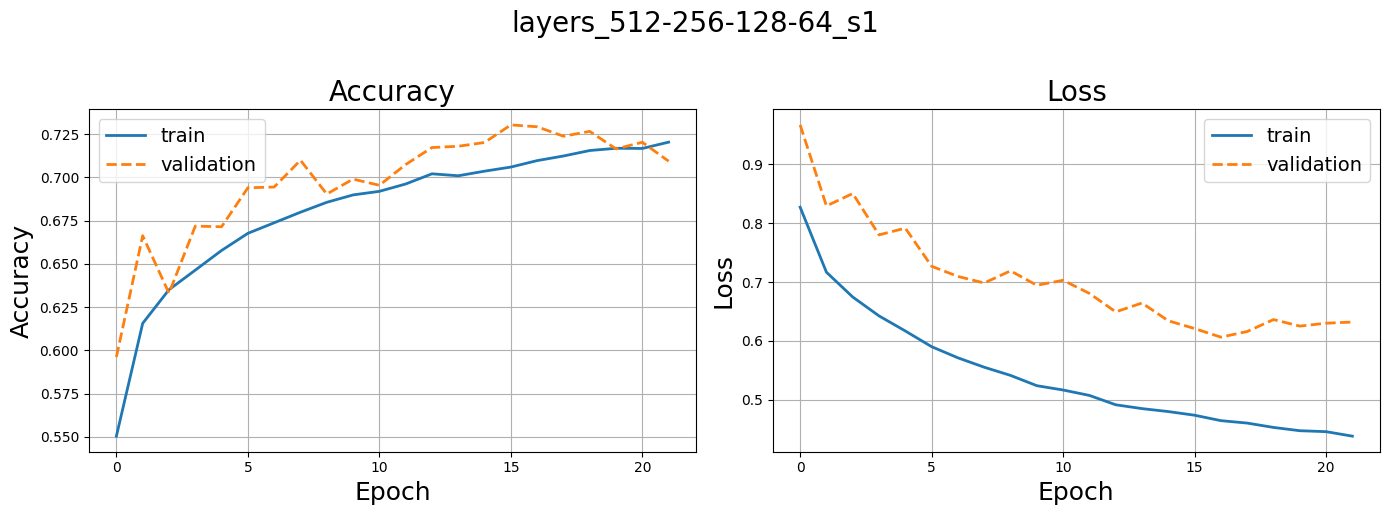

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


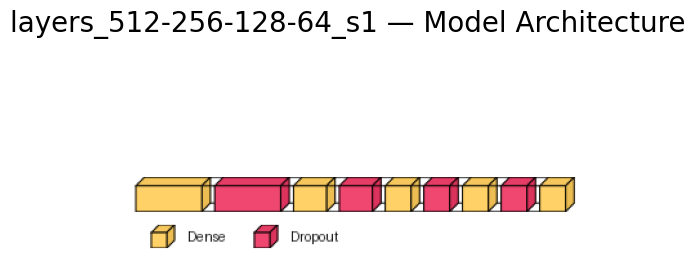

717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


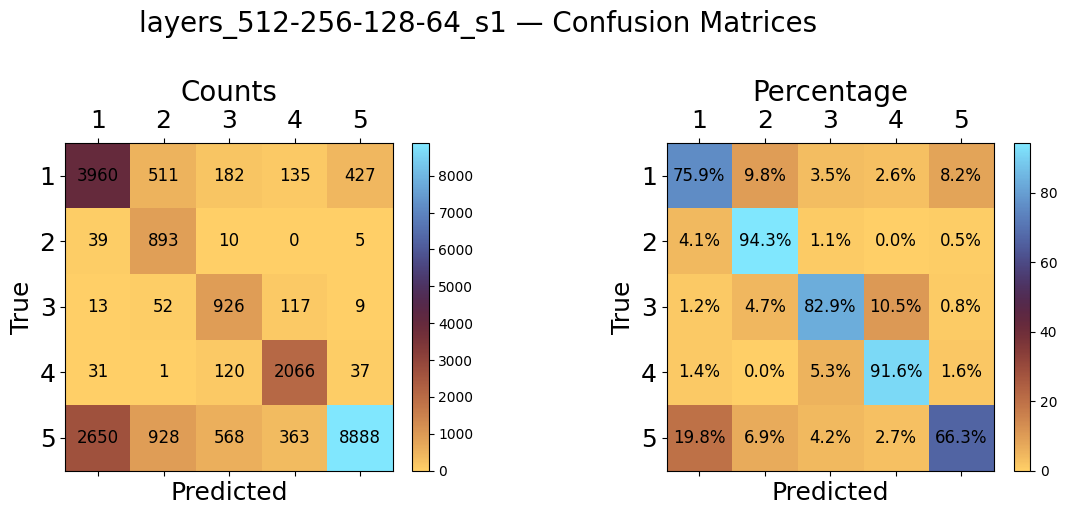

Pesos de classe originais: {np.float64(0.0): np.float64(0.8793770801660024), np.float64(1.0): np.float64(4.843041412084182), np.float64(2.0): np.float64(4.1038159156279965), np.float64(3.0): np.float64(2.0339669264398403), np.float64(4.0): np.float64(0.34234571455993856)}
Pesos de classe modificados: {np.float64(0.0): np.float64(0.8793770801660024), np.float64(1.0): np.float64(4.843041412084182), np.float64(2.0): np.float64(4.1038159156279965), np.float64(3.0): np.float64(2.0339669264398403), np.float64(4.0): np.float64(0.2738765716479509)}
Epoch 1/500


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


418/418 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4672 - loss: 0.9468 - val_accuracy: 0.5982 - val_loss: 0.9805
Epoch 2/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6022 - loss: 0.7442 - val_accuracy: 0.6159 - val_loss: 0.9154
Epoch 3/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6253 - loss: 0.6972 - val_accuracy: 0.6581 - val_loss: 0.8376
Epoch 4/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6419 - loss: 0.6652 - val_accuracy: 0.6534 - val_loss: 0.8150
Epoch 5/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6514 - loss: 0.6295 - val_accuracy: 0.6628 - val_loss: 0.7889
Epoch 6/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6563 - loss: 0.6083 - val_accuracy: 0.6505 - val_loss: 0.8115
Epoch 7/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6630 - loss: 0.5815 - val_accuracy: 0.6896 - val_loss: 0.7400
Epoch 8/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6702 - loss: 0.5758 - val_accuracy: 0.703

717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


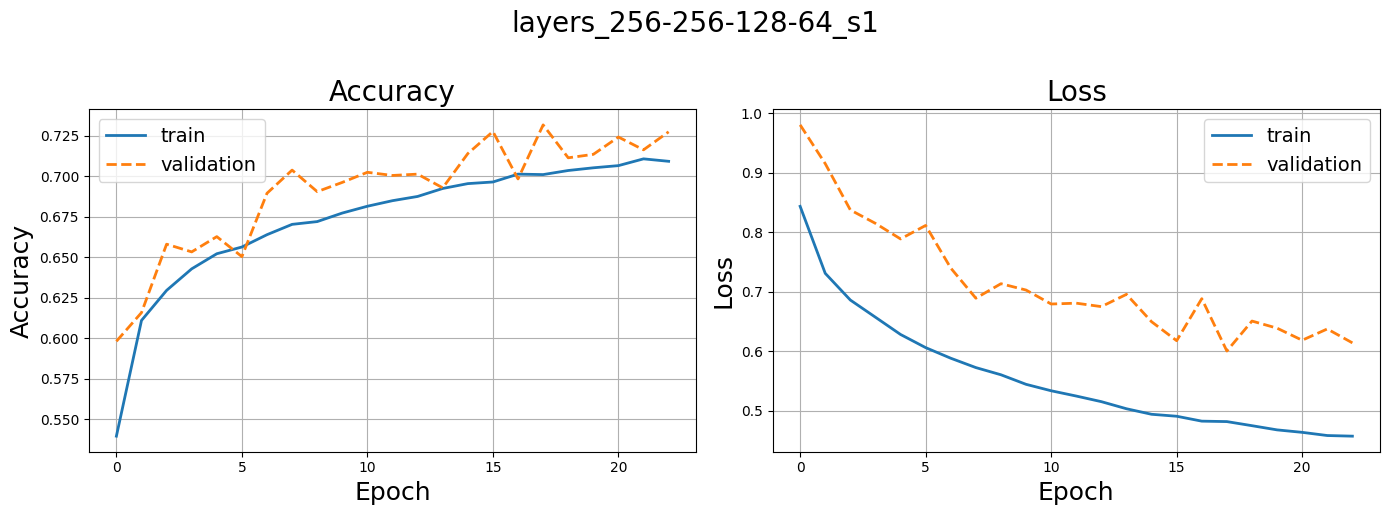

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


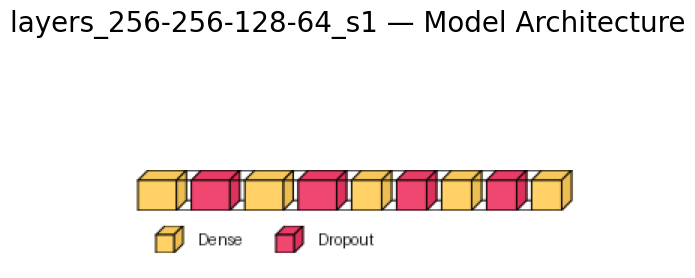

717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


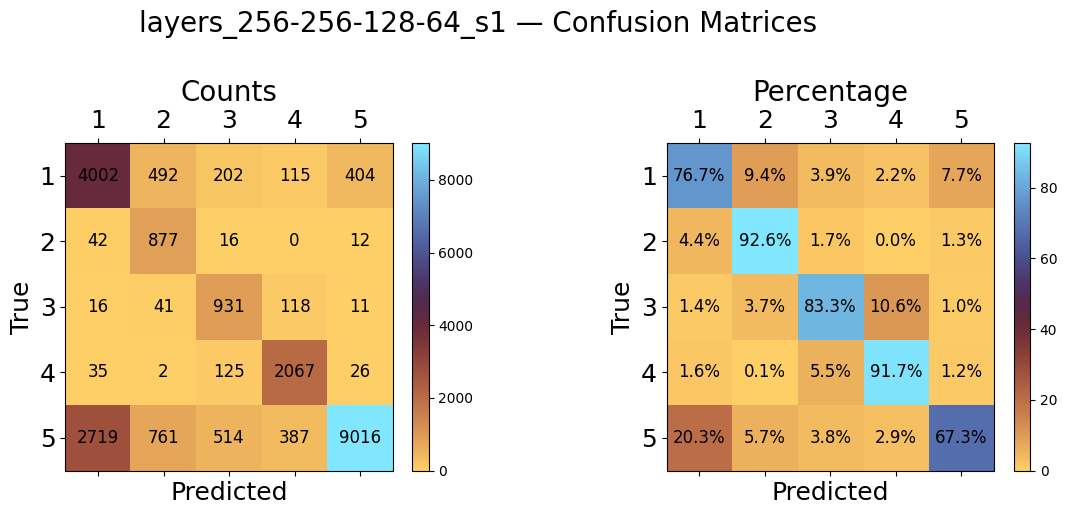

Pesos de classe originais: {np.float64(0.0): np.float64(0.8793770801660024), np.float64(1.0): np.float64(4.843041412084182), np.float64(2.0): np.float64(4.1038159156279965), np.float64(3.0): np.float64(2.0339669264398403), np.float64(4.0): np.float64(0.34234571455993856)}
Pesos de classe modificados: {np.float64(0.0): np.float64(0.8793770801660024), np.float64(1.0): np.float64(4.843041412084182), np.float64(2.0): np.float64(4.1038159156279965), np.float64(3.0): np.float64(2.0339669264398403), np.float64(4.0): np.float64(0.2738765716479509)}
Epoch 1/500


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


418/418 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4108 - loss: 1.0432 - val_accuracy: 0.6018 - val_loss: 0.9640
Epoch 2/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5781 - loss: 0.7792 - val_accuracy: 0.6176 - val_loss: 0.9293
Epoch 3/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6062 - loss: 0.7326 - val_accuracy: 0.6315 - val_loss: 0.8961
Epoch 4/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6219 - loss: 0.7098 - val_accuracy: 0.6390 - val_loss: 0.8777
Epoch 5/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6318 - loss: 0.6796 - val_accuracy: 0.6500 - val_loss: 0.8478
Epoch 6/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6386 - loss: 0.6645 - val_accuracy: 0.6787 - val_loss: 0.7979
Epoch 7/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6469 - loss: 0.6471 - val_accuracy: 0.6623 - val_loss: 0.8057
Epoch 8/500
418/418 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6480 - loss: 0.6317 - val_accuracy: 0.66

717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


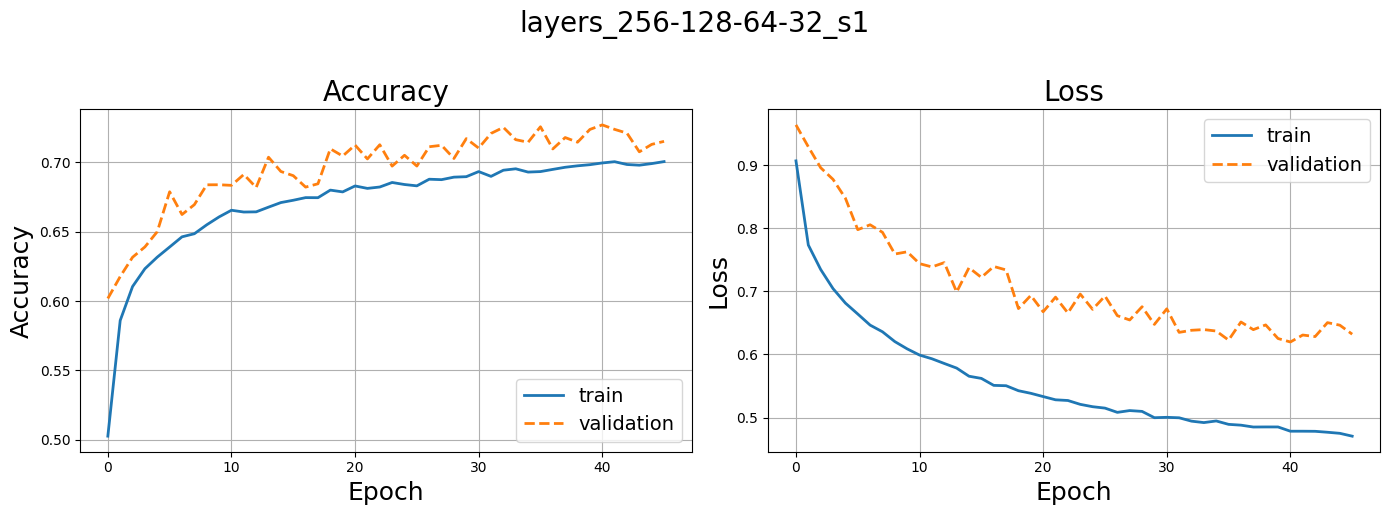

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


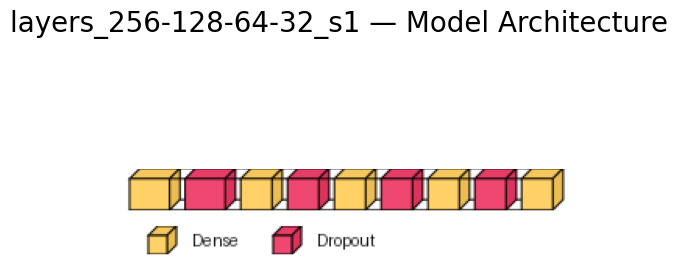

717/717 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


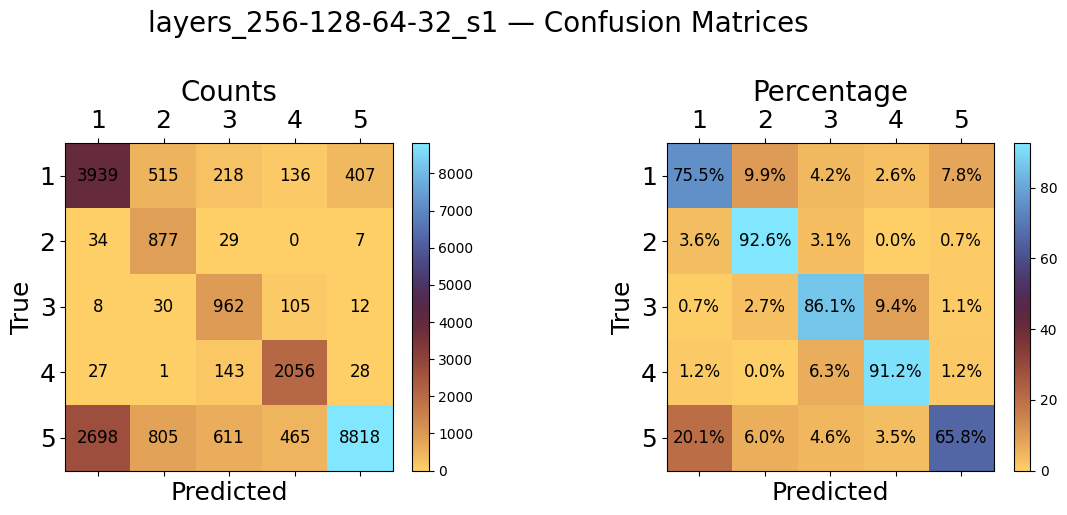

Saved all_experiments_metrics.csv


In [ ]:
# @title 6) Loop de experimentos e coleta de métricas
root = "/content/drive/MyDrive/gaitanalisys"
experiments = [
    {'layers': [512,256,128,64],     'sensors': [4]},
    {'layers': [256,256,128,64],     'sensors': [4]},
    {'layers': [256,128,64,32],         'sensors': [4]},

]

all_metrics = []

for exp in experiments:
    name = f"layers_{'-'.join(map(str,exp['layers']))}_s{len(exp['sensors'])}"
    X_tr, X_vl, X_te, y_tr, y_vl, y_te, cw = load_data(root)
    model = build_model(exp['layers'], X_tr.shape[1], num_classes=len(np.unique(y_tr)))
    history, t_time = train_model(model, X_tr, y_tr, X_vl, y_vl, class_weights=cw)
    model.save(f'/content/drive/MyDrive/gaitanalisys/modeltrainado{name}.weights.h5')
    y_pred = np.argmax(model.predict(X_te), axis=1)
    m = collect_metrics(name, history, y_te, y_pred, t_time)
    all_metrics.append(m)
    plot_single_experiment(history, model, X_te, y_te, name)

# cria DataFrame com métricas e salva
df_metrics = pd.DataFrame(all_metrics)
df_metrics.to_csv(f"{root}/all_experiments_metrics.csv", index=False)
print("Saved all_experiments_metrics.csv")

In [ ]:
# @title 7) visualização das métricas
# 1) Caso ainda não tenha montado o Drive (Colab):
from google.colab import drive
drive.mount('/content/drive')

# 2) Import e leitura do CSV de métricas
import pandas as pd

metrics_path = f"{root}/all_experiments_metrics.csv"
df_metrics = pd.read_csv(metrics_path)

# 3) Visualização rápida
print(df_metrics.shape)
display(df_metrics)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(3, 10)


,experiment,accuracy,precision,recall,f1_score,RAE,RSE,R2,training_time_s,epochs
0,layers_512-256-128-64_s1,0.729711,0.805190,0.729711,0.742813,0.541602,0.991146,0.008854,54.258625,22
1,layers_256-256-128-64_s1,0.736688,0.807529,0.736688,0.748745,0.529770,0.976122,0.023878,59.757390,23
2,layers_256-128-64-32_s1,0.726179,0.802538,0.726179,0.738654,0.541426,0.987086,0.012914,96.776075,46


In [ ]:
# 1) Caso ainda não tenha montado o Drive (Colab):
from google.colab import drive
drive.mount('/content/drive')

# 2) Import e leitura do CSV de métricas
import pandas as pd

metrics_path = f"{root}/all_experiments_metrics.csv"
df_metrics = pd.read_csv(metrics_path)

# 3) Arredonda todas as colunas numéricas para 4 casas decimais
df_rounded = df_metrics.round(4)

# 4) Salva novo CSV com os valores arredondados
rounded_path = f"{root}/all_experiments_metrics_rounded.csv"
df_rounded.to_csv(rounded_path, index=False)
print(f"Saved rounded metrics to {rounded_path}")

# 5) Visualização rápida do resultado
display(df_rounded.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved rounded metrics to /content/drive/MyDrive/gaitanalisys/all_experiments_metrics_rounded.csv


,experiment,accuracy,precision,recall,f1_score,RAE,RSE,R2,training_time_s,epochs
0,layers_512-256-128-64_s1,0.7297,0.8052,0.7297,0.7428,0.5416,0.9911,0.0089,54.2586,22
1,layers_256-256-128-64_s1,0.7367,0.8075,0.7367,0.7487,0.5298,0.9761,0.0239,59.7574,23
2,layers_256-128-64-32_s1,0.7262,0.8025,0.7262,0.7387,0.5414,0.9871,0.0129,96.7761,46
